In [8]:
# Importando as bibliotecas
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Configurando o formato dos números decimais para exibição no Notebook
pd.options.display.float_format = '{:.2f}'.format

In [9]:
# Carregando a base tratada e removendo a linha 'Total' para não distorcer as estatísticas
df = pd.read_csv('dados\DATABASE_LIMPO.csv')
df_analise = df[df['Região Metropolitana - RIDE'] != 'Total']

# Verificando o tamanho da base de dados filtrada
linhas, colunas = df_analise.shape
print(f"Base de dados pronta: {linhas} regiões e {colunas} colunas.")

Base de dados pronta: 12 regiões e 12 colunas.


<>:2: SyntaxWarning: invalid escape sequence '\D'
<>:2: SyntaxWarning: invalid escape sequence '\D'
C:\Users\gwazo\AppData\Local\Temp\ipykernel_31612\1538723679.py:2: SyntaxWarning: invalid escape sequence '\D'
  df = pd.read_csv('dados\DATABASE_LIMPO.csv')


In [10]:
# Verificando a estrutura técnica das colunas (tipos de dados)
print("--- INFORMAÇÕES TÉCNICAS ---")
df_analise.info()
print("\n" + "-"*50 + "\n")

# Gerando a tabela estatística geral das colunas numéricas
print("--- RESUMO ESTATÍSTICO GERAL ---")
df_analise.describe()

--- INFORMAÇÕES TÉCNICAS ---
<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 12 columns):
 #   Column                                            Non-Null Count  Dtype
---  ------                                            --------------  -----
 0   Região Metropolitana - RIDE                       12 non-null     str  
 1   Rede geral - sem informação de canalização        12 non-null     int64
 2   Poço ou nascente - sem informação de canalização  12 non-null     int64
 3   Poço ou nascente fora da propriedade              12 non-null     int64
 4   Carro-Pipa                                        12 non-null     int64
 5   Água da chuva armazenada em cisterna              12 non-null     int64
 6   Água da chuva armazenada outra forma              12 non-null     int64
 7   Rio, açude, lago ou igarapé                       12 non-null     int64
 8   Poço ou nascente na aldeia                        12 non-null     int64
 9   Poço ou nascente fora da al

,Rede geral - sem informação de canalização,Poço ou nascente - sem informação de canalização,Poço ou nascente fora da propriedade,Carro-Pipa,Água da chuva armazenada em cisterna,Água da chuva armazenada outra forma,"Rio, açude, lago ou igarapé",Poço ou nascente na aldeia,Poço ou nascente fora da aldeia,Outra,Total
count,12.00,12.00,12.00,12.00,12.00,12.00,12.00,12.00,12.00,12.00,12.00
mean,3236780.17,127525.08,29301.92,2606.00,190.75,238.00,2900.25,105.67,11.92,12273.58,3411933.33
std,5674692.00,220084.98,43106.41,5794.06,403.20,446.43,4134.09,237.41,40.65,28450.96,5882184.07
min,108390.00,6417.00,4597.00,7.00,8.00,7.00,155.00,0.00,0.00,116.00,120076.00
25%,456298.50,16400.50,7552.25,73.00,13.25,15.75,439.25,0.00,0.00,571.50,493401.50
50%,1086453.50,38471.00,13725.00,752.50,29.50,55.50,609.50,0.00,0.00,1095.50,1135982.00
75%,1863826.00,106091.75,26650.00,1848.50,95.75,148.50,3637.50,17.75,0.00,7137.75,1982304.75
max,19084981.00,772397.00,158645.00,20671.00,1376.00,1505.00,12117.00,661.00,141.00,100156.00,19560134.00


In [11]:
# Função para extrair medidas de tendência central, posição e dispersão de cada coluna
def analisar_colunas_individuais(tabela):
    array_de_colunas = []
    for nome_coluna in tabela.columns:
        if pd.api.types.is_numeric_dtype(tabela[nome_coluna]):
            array_de_colunas.append(nome_coluna)
            coluna_isolada = tabela[nome_coluna]

            contagem = coluna_isolada.count()
            media = coluna_isolada.mean()
            mediana = coluna_isolada.median()
            listaModa = coluna_isolada.mode()
            moda = listaModa[0] if len(listaModa) > 0 else 0

            minimo = coluna_isolada.min()
            primeiroQuartil = coluna_isolada.quantile(0.25)
            terceiroQuartil = coluna_isolada.quantile(0.75)
            maximo = coluna_isolada.max()

            desvioPadrao = coluna_isolada.std()
            variancia = coluna_isolada.var()
            amplitude = maximo - minimo
            iqr = terceiroQuartil - primeiroQuartil
            cv = (desvioPadrao / media) * 100 if media != 0 else 0

            print(f"Análise: {nome_coluna}")
            print(f"Quantidade de amostras: {contagem} regiões")
            print("TENDÊNCIA CENTRAL:")
            print(f"  Média: {media:.2f} | Mediana: {mediana:.2f} | Moda: {moda:.2f}")
            print("MEDIDAS DE POSIÇÃO:")
            print(f"  Mínimo: {minimo:.2f} | 1º Quartil (Q1): {primeiroQuartil:.2f} | 3º Quartil (Q3): {terceiroQuartil:.2f} | Máximo: {maximo:.2f}")
            print("MEDIDAS DE DISPERSÃO:")
            print(f"  Amplitude: {amplitude:.2f} | IQR: {iqr:.2f}")
            print(f"  Variância: {variancia:.2f} | Desvio Padrão: {desvioPadrao:.2f} | CV: {cv:.2f}%")
            print("=" * 60 + "\n")
    return array_de_colunas

# Executando a análise detalhada por coluna
print("Iniciando análise estatística individualizada...\n")
minhas_colunas_salvas = analisar_colunas_individuais(df_analise)

Iniciando análise estatística individualizada...

Análise: Rede geral - sem informação de canalização
Quantidade de amostras: 12 regiões
TENDÊNCIA CENTRAL:
  Média: 3236780.17 | Mediana: 1086453.50 | Moda: 108390.00
MEDIDAS DE POSIÇÃO:
  Mínimo: 108390.00 | 1º Quartil (Q1): 456298.50 | 3º Quartil (Q3): 1863826.00 | Máximo: 19084981.00
MEDIDAS DE DISPERSÃO:
  Amplitude: 18976591.00 | IQR: 1407527.50
  Variância: 32202129298848.89 | Desvio Padrão: 5674692.00 | CV: 175.32%

Análise: Poço ou nascente - sem informação de canalização
Quantidade de amostras: 12 regiões
TENDÊNCIA CENTRAL:
  Média: 127525.08 | Mediana: 38471.00 | Moda: 6417.00
MEDIDAS DE POSIÇÃO:
  Mínimo: 6417.00 | 1º Quartil (Q1): 16400.50 | 3º Quartil (Q3): 106091.75 | Máximo: 772397.00
MEDIDAS DE DISPERSÃO:
  Amplitude: 765980.00 | IQR: 89691.25
  Variância: 48437396706.99 | Desvio Padrão: 220084.98 | CV: 172.58%

Análise: Poço ou nascente fora da propriedade
Quantidade de amostras: 12 regiões
TENDÊNCIA CENTRAL:
  Média: 29

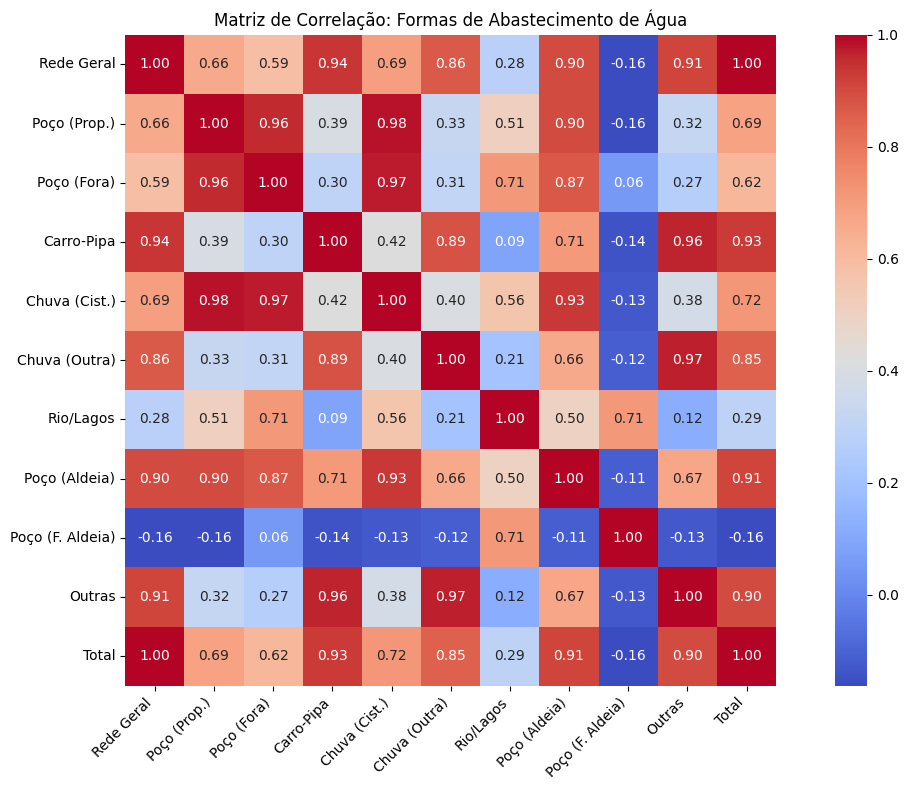

In [12]:
# Filtrando apenas colunas numéricas e aplicando apelidos curtos para melhorar o visual do gráfico
df_numerico = df_analise.select_dtypes(include=['number'])
apelidos = {
    'Rede geral - sem informação de canalização': 'Rede Geral',
    'Poço ou nascente - sem informação de canalização': 'Poço (Prop.)',
    'Poço ou nascente fora da propriedade': 'Poço (Fora)',
    'Carro-Pipa': 'Carro-Pipa',
    'Água da chuva armazenada em cisterna': 'Chuva (Cist.)',
    'Água da chuva armazenada outra forma': 'Chuva (Outra)',
    'Rio, açude, lago ou igarapé': 'Rio/Lagos',
    'Poço ou nascente na aldeia': 'Poço (Aldeia)',
    'Poço ou nascente fora da aldeia': 'Poço (F. Aldeia)',
    'Outra': 'Outras'
}
df_numerico_curto = df_numerico.rename(columns=apelidos)
matriz_corr = df_numerico_curto.corr()

# Configurando e gerando o Mapa de Calor (Heatmap)
plt.figure(figsize=(12, 8))
sns.heatmap(matriz_corr, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title('Matriz de Correlação: Formas de Abastecimento de Água')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Salvando e exibindo o gráfico diretamente no notebook
plt.savefig('correlacao.png')
plt.show()

In [13]:
# Verificação de integridade: Buscando por valores nulos (faltantes)
print("--- AUDITORIA: VALORES MISSING/NULOS ---")
valores_nulos = df_analise.isnull().sum()
colunas_com_nulos = valores_nulos[valores_nulos > 0]
if colunas_com_nulos.empty:
    print("Sucesso: Não existem valores faltantes na base analisada.")
else:
    print(colunas_com_nulos)

print("\n" + "-"*50 + "\n")

# Verificação de integridade: Buscando por valores negativos que não fazem sentido lógico
print("--- AUDITORIA: VALORES NEGATIVOS INCONSISTENTES ---")
df_numerico_auditoria = df_analise.select_dtypes(include=['number'])
valores_negativos = (df_numerico_auditoria < 0).sum()
colunas_com_negativos = valores_negativos[valores_negativos > 0]
if colunas_com_negativos.empty:
    print("Sucesso: Nenhum valor logicamente incorreto (negativo) encontrado.")
else:
    print("Atenção! Valores negativos inconsistentes encontrados:")
    print(colunas_com_negativos)

--- AUDITORIA: VALORES MISSING/NULOS ---
Sucesso: Não existem valores faltantes na base analisada.

--------------------------------------------------

--- AUDITORIA: VALORES NEGATIVOS INCONSISTENTES ---
Sucesso: Nenhum valor logicamente incorreto (negativo) encontrado.


In [14]:
# Função para mapear outliers em cada coluna usando a regra do IQR (Linha de corte: Q3 + 1.5*IQR)
def relatorio_geral_outliers(tabela):
    df_numerico = tabela.select_dtypes(include=['number']).drop(columns=['Total'], errors='ignore')
    for nome_coluna in df_numerico.columns:
        Q1 = tabela[nome_coluna].quantile(0.25)
        Q3 = tabela[nome_coluna].quantile(0.75)
        IQR = Q3 - Q1
        limite_superior = Q3 + 1.5 * IQR
        outliers = tabela[tabela[nome_coluna] > limite_superior]

        if not outliers.empty:
            print(f"Coluna: {nome_coluna.upper()} contém anomalias (Outliers)")
            print(f"  Linha de corte calculada: Acima de {limite_superior:.2f}")
            for index, linha in outliers.iterrows():
                regiao = linha['Região Metropolitana - RIDE']
                valor = linha[nome_coluna]
                print(f"   -> {regiao}: {valor:.0f} domicílios")
            print("-" * 40)

# Executando a verificação de outliers nas regiões de São Paulo / IBGE
print("Buscando por anomalias/outliers na distribuição dos dados...\n")
relatorio_geral_outliers(df_analise)

Buscando por anomalias/outliers na distribuição dos dados...

Coluna: REDE GERAL - SEM INFORMAÇÃO DE CANALIZAÇÃO contém anomalias (Outliers)
  Linha de corte calculada: Acima de 3975117.25
   -> São Paulo: 19084981 domicílios
   -> Interior (Fora RM): 10022582 domicílios
----------------------------------------
Coluna: POÇO OU NASCENTE - SEM INFORMAÇÃO DE CANALIZAÇÃO contém anomalias (Outliers)
  Linha de corte calculada: Acima de 240628.62
   -> São Paulo: 296324 domicílios
   -> Interior (Fora RM): 772397 domicílios
----------------------------------------
Coluna: POÇO OU NASCENTE FORA DA PROPRIEDADE contém anomalias (Outliers)
  Linha de corte calculada: Acima de 55296.62
   -> Interior (Fora RM): 158645 domicílios
----------------------------------------
Coluna: CARRO-PIPA contém anomalias (Outliers)
  Linha de corte calculada: Acima de 4511.75
   -> São Paulo: 20671 domicílios
----------------------------------------
Coluna: ÁGUA DA CHUVA ARMAZENADA EM CISTERNA contém anomalias (O